In [1]:
from opticalib.ground import osutils as osu

from astropy.io import fits

import matplotlib.pyplot as plt
import numpy as np
import os


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 5060`
       Memory = 7884.61 MB | Compute Capability = 12.0
       Using CuPy 13.6.0 for acceleration.


In [2]:
def computeRadialProfile(image, centerInPxY=None, centerInPxX=None):
    if centerInPxX is None:
        centerInPxX = image[1].shape//2
    if centerInPxY is None:
        centerInPxY = image[0].shape//2
    yCoord, xCoord= np.indices(image.shape)
    yCoord= (yCoord - centerInPxY)
    xCoord= (xCoord - centerInPxX)
    rCoord=np.sqrt(xCoord**2 + yCoord**2)
    indexR= np.argsort(rCoord.flat)
    radialDistancesSorted= rCoord.flat[indexR]
    imageValuesSortedByRadialDistance= image.flat[indexR]
    integerPartOfRadialDistances= radialDistancesSorted.astype(np.int64)
    deltaRadialDistance= integerPartOfRadialDistances[1:] - \
        integerPartOfRadialDistances[:-1]
    radialDistanceChanges= np.where(deltaRadialDistance)[0]
    nPxInBinZero= radialDistanceChanges[0]+ 1
    nPxInRadialBin= radialDistanceChanges[1:] - \
        radialDistanceChanges[:-1]
    imageRadialCumSum= np.cumsum(imageValuesSortedByRadialDistance,
                                 dtype=np.float64)
    imageSumInBinZero= imageRadialCumSum[radialDistanceChanges[0]]
    imageSumInRadialBin= \
        imageRadialCumSum[radialDistanceChanges[1:]] - \
        imageRadialCumSum[radialDistanceChanges[:-1]]
    profileInZero= imageSumInBinZero / nPxInBinZero
    profileFromOne= imageSumInRadialBin / nPxInRadialBin
    profile= np.hstack([profileInZero, profileFromOne])

    distanceRadialCumSum= np.cumsum(radialDistancesSorted)
    distanceSumInBinZero= distanceRadialCumSum[radialDistanceChanges[0]]
    distanceSumInRadialBin= \
        distanceRadialCumSum[radialDistanceChanges[1:]] - \
        distanceRadialCumSum[radialDistanceChanges[:-1]]
    distanceInZero= distanceSumInBinZero / nPxInBinZero
    distanceFromOne= distanceSumInRadialBin / nPxInRadialBin
    radialDistance= np.hstack([distanceInZero, distanceFromOne])
    return profile, radialDistance


def get_photocenter(image):
    ny, nx = image.shape
    x = np.arange(nx)
    y = np.arange(ny)
    X,Y = np.meshgrid(x, y)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    return qx,qy 


def best_circle_fit(image,show_fit:bool=True):
    """Estimate the center coordinates and radius of a circular bright
    feature in *image*.

    Parameters
    ----------
    image : 2-D ndarray
        Input intensity map.  The algorithm finds pixels above a threshold
        (default 50%% of the maximum value) and fits a circle to their
        locations using a simple algebraic least-squares method.
    show_fit : bool
        If ``True`` generate a figure showing the input image with the
        fitted circle overlaid as a dashed blue line and the estimated
        center marked with a cross.

    Returns
    -------
    cx, cy : float
        Estimated center coordinates (x along columns, y along rows).
    radius : float
        Radius of the fitted circle in pixel units.  If the fit fails, a
        radius of ``np.nan`` is returned.
    """
    arr = np.asarray(image, dtype=np.float64)
    maxv = arr.max()
    thresh = 0.5 * maxv
    ys, xs = np.nonzero(arr >= thresh)
    if len(xs) < 3:
        cx, cy = get_photocenter(arr)
        if show_fit:
            plt.figure()
            plt.imshow(arr, origin='lower', cmap='gray')
            plt.plot(cy, cx, '+', c='C0')
        return cx, cy, 0.0

    x = xs.astype(np.float64)
    y = ys.astype(np.float64)
    A = np.column_stack([2 * x, 2 * y, np.ones_like(x)])
    b = x * x + y * y
    c, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy, c0 = c
    radius = np.sqrt(cx * cx + cy * cy + c0)

    if show_fit:
        plt.figure()
        plt.imshow(arr, origin='lower', cmap='gray')
        theta = np.linspace(0, 2*np.pi, 200)
        circle_x = cx + radius * np.cos(theta)
        circle_y = cy + radius * np.sin(theta)
        plt.plot(circle_x, circle_y, '--', c='C0')
        plt.plot(cy, cx, '+', c='C0')

    return cx, cy, radius


In [3]:


def best_ellipse_fit(image, show_fit:bool=True):
    """Fit an ellipse to the brightest region of an image.

    The method thresholds the input at half the maximum value and fits an
    algebraic conic to the selected pixel coordinates.  If the resulting
    conic represents an ellipse, the centre, major/minor semi-axes and
    orientation angle are returned.  When ``show_fit`` is ``True`` a
    diagnostic figure with the overlayed ellipse is produced.

    Parameters
    ----------
    image : 2-D ndarray
        Intensity map containing a roughly elliptical bright feature.
    show_fit : bool
        Whether to plot the fit on top of the image (dashed blue line,
        centre marked with a cross).

    Returns
    -------
    cx, cy : float
        Coordinates of the ellipse centre (x columns, y rows).
    a, b : float
        Semi-major and semi-minor axis lengths in pixels.  ``a`` is the
        larger of the two.
    theta : float
        Rotation angle of the major axis measured counter‑clockwise from
        the x-axis (columns) in radians.

    Notes
    -----
    The function falls back to ``best_circle_fit`` if there are too few
    points or the fit is not an ellipse.  In such cases ``a`` and ``b``
    are equal and ``theta`` is zero.
    """
    arr = np.asarray(image, dtype=np.float64)
    maxv = arr.max()

    thresh = 0.5 * maxv
    ys, xs = np.nonzero(arr >= thresh)
    if len(xs) < 5:
        # not enough points for an ellipse; delegate to circle fitter
        cx, cy, r = best_circle_fit(arr, show_fit=show_fit)
        return cx, cy, r, r, 0.0

    x = xs.astype(np.float64)
    y = ys.astype(np.float64)

    # design matrix for conic: A x^2 + B xy + C y^2 + D x + E y + F = 0
    Dmat = np.vstack([x*x, x*y, y*y, x, y, np.ones_like(x)]).T
    # find nullspace vector via SVD (smallest singular value)
    _, _, Vt = np.linalg.svd(Dmat, full_matrices=False)
    A, B, C, D, E, F = Vt[-1, :]

    # ensure we have an ellipse: B^2 - 4AC < 0
    if B*B - 4*A*C >= 0:
        # degenerate: fall back to circle
        cx, cy, r = best_circle_fit(arr, show_fit=show_fit)
        return cx, cy, r, r, 0.0

    # centre of ellipse
    denom = (B*B - 4*A*C)
    cx = (2*C*D - B*E) / denom
    cy = (2*A*E - B*D) / denom

    # orientation angle
    theta = 0.5 * np.arctan2(B, A - C)

    # semi-axes lengths
    up = 2 * (A*E*E + C*D*D - B*D*E + denom*F)
    term = np.sqrt((A - C)**2 + B*B)
    down1 = (denom) * ((C - A) + term)
    down2 = (denom) * ((C - A) - term)
    # protect against negative under sqrt due to numerical error
    if up / down1 <= 0 or up / down2 <= 0:
        cx, cy, r = best_circle_fit(arr, show_fit=show_fit)
        return cx, cy, r, r, 0.0
    a = np.sqrt(up / down1)
    b = np.sqrt(up / down2)
    # ensure a >= b
    if b > a:
        a, b = b, a
        theta += np.pi/2

    if show_fit:
        plt.figure()
        plt.imshow(arr, origin='lower', cmap='gray')
        t = np.linspace(0, 2*np.pi, 400)
        cos_t = np.cos(t)
        sin_t = np.sin(t)
        # parametric ellipse before rotation
        xe = a * cos_t
        ye = b * sin_t
        # rotate and translate
        xr = cx + xe * np.cos(theta) - ye * np.sin(theta)
        yr = cy + xe * np.sin(theta) + ye * np.cos(theta)
        plt.plot(xr, yr, '--', c='C0')
        plt.plot(cy, cx, '+', c='C0')

    return cx, cy, a, b, theta


(1e-06, 0.01)

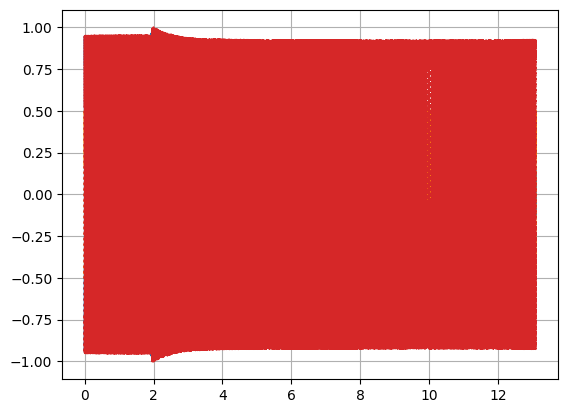

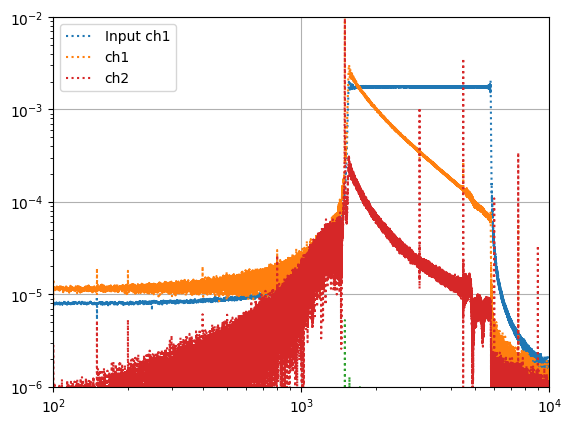

In [4]:
webdaqpath = '/mnt/jumbo/SPLATT/WebDaqData'
freq = 51200

def read_wbdq_data(tn,show:bool=False):
    filename = os.path.join(webdaqpath,tn)+'.fits'
    data = osu.load_fits(filename)
    # raw_data = osu.load_fits(filename)
    # raw_data = raw_data.flatten()
    # data = np.zeros((4, len(raw_data)//4))
    # for i in range(4):
    #     data[i] = raw_data[i::4]
    tvec = np.arange(data.shape[1])/freq
    if show:
        plt.figure()
        plt.plot(tvec,data[1],':')
        plt.plot(tvec,data[0],':')
        plt.plot(tvec,data[2],':')
        plt.plot(tvec,data[3],':')
        plt.grid()
        # plt.xlim([0,0.001])
    return data, tvec

def get_spectrum(signal, dt=1, phase = False):
    spe = np.fft.rfft(signal, norm="ortho")
    nn = np.sqrt(len(spe))
    spe_mod = (np.abs(spe)) / nn
    freq = np.fft.rfftfreq(len(signal), d=dt)
    spe_mod[0] = 0
    if phase is True:
        spe_phi = np.angle(spe)
        return spe_mod, freq, spe_phi
    else:
        return spe_mod, freq
    
data,tvec = read_wbdq_data('20260224_180203',show=True)
tstart = 2
tend = 11.5
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]

spe1,f = get_spectrum(data[0], dt=1/freq)
spe2,f = get_spectrum(data[1], dt=1/freq)
spe3,f = get_spectrum(data[2], dt=1/freq)
spe4,f = get_spectrum(data[3], dt=1/freq)
plt.figure()
plt.plot(f,spe1,':',label='Input ch1')
plt.plot(f,spe2,':',label='ch1')
plt.plot(f,spe3,':',label='')
plt.plot(f,spe4,':',label='ch2')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e+2,1e+4])
plt.ylim([1e-6,1e-2])

In [5]:
path = '/mnt/libero/S331sl'

def plot_tn_list(tn_list,xlim=None,ylim=None):
    img = None
    for tn in tn_list:
        try:
            filename = os.path.join(path,tn)+'.fits'
            data = osu.load_fits(filename)
        except FileNotFoundError:
            data = osu.load_fits(tn)
        if img is None:
            img = np.array(data,dtype=np.float64).copy()
        else:
            img += np.array(data,dtype=np.float64)
    plt.figure()
    plt.imshow(img,origin='lower',cmap='gray')
    plt.colorbar()
    plt.xlim(xlim)
    plt.ylim(ylim)
    return img

def get_radial_profiles(tn_list,cx,cy,show:bool=False):
    rad_profile = None
    N = len(tn_list)
    if show:
        plt.figure()
    for tn in tn_list:        
        try:
            filename = os.path.join(path,tn)+'.fits'
            data = osu.load_fits(filename)
        except FileNotFoundError:
            data = osu.load_fits(tn)
        profile, pix_dist = computeRadialProfile(np.array(data),cx,cy)
        if show:
            plt.plot(pix_dist,profile,'--')
        if rad_profile is None:
            rad_profile = np.array(profile).copy()
        else:
            rad_profile = np.hstack([rad_profile,np.array(profile)])
    if show:
        plt.grid()
        plt.xscale('log')
        plt.yscale('log')
    rad_profile = rad_profile.reshape([N,len(profile)])
    return rad_profile, pix_dist
    



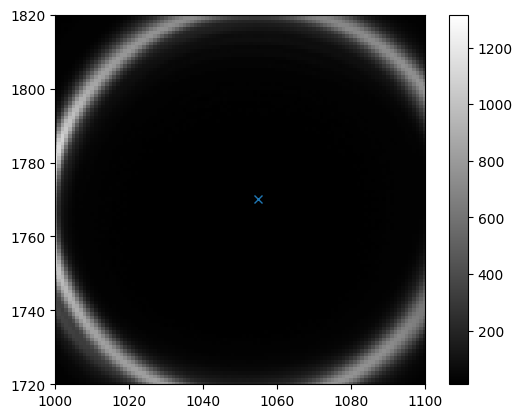

In [6]:
tn_list = ['20260220_164753','20260220_164854','20260220_164955','20260220_165055','20260220_165156',
           '20260220_165257','20260220_165358','20260220_165459','20260220_165600','20260220_165701',
           '20260220_170143','20260220_170217']

pix2mrad = 3.45/200

img = plot_tn_list(tn_list,xlim=[1000,1100],ylim=[1720,1820])
# qx,qy = get_photocenter(img[1600:1900,900:1200])
cy = 1055
cx = 1770
plt.plot(cy,cx,'x')

Text(0.5, 1.0, '20260220_162938')

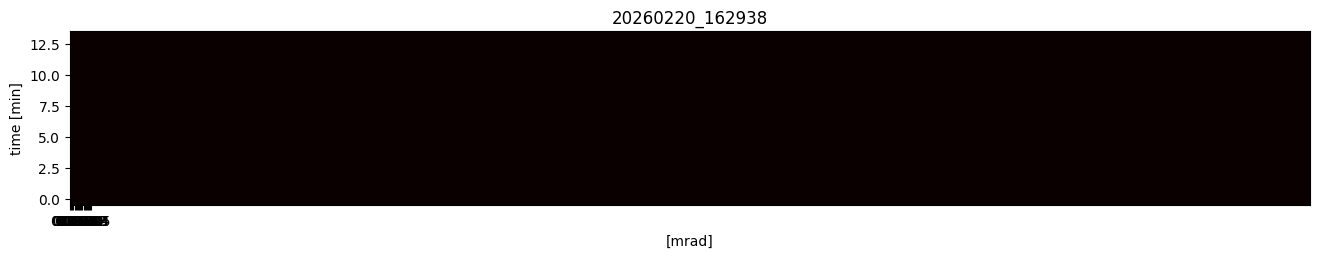

In [ ]:
rad_profile, pix_dist = get_radial_profiles(tn_list,cx,cy)
norm_rad_profile = rad_profile/np.max(rad_profile[:,:100],axis=1)[:,None]
plt.figure(figsize=(16,6))
plt.imshow(norm_rad_profile, cmap='hot')
plt.xlim([0, 100])
plt.xlabel('[pix]')
plt.ylabel('time [min]')
plt.title(tn_list[0])

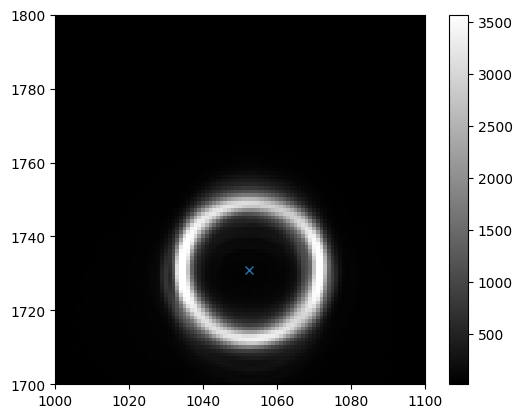

In [8]:
tn_list = ['20260220_162938','20260220_163048','20260220_163159','20260220_163310',
           '20260220_163421','20260220_163532','20260220_163643','20260220_163754',
           '20260220_163905','20260220_164016','20260220_164126','20260220_164237',
           '20260220_164348','20260220_164459']
img = plot_tn_list(tn_list,xlim=[1000,1100],ylim=[1700,1800])
# qx,qy = get_photocenter(img[1600:1900,900:1200])
cy = 1052.5
cx = 1731
plt.plot(cy,cx,'x')

(0.0, 50.0)

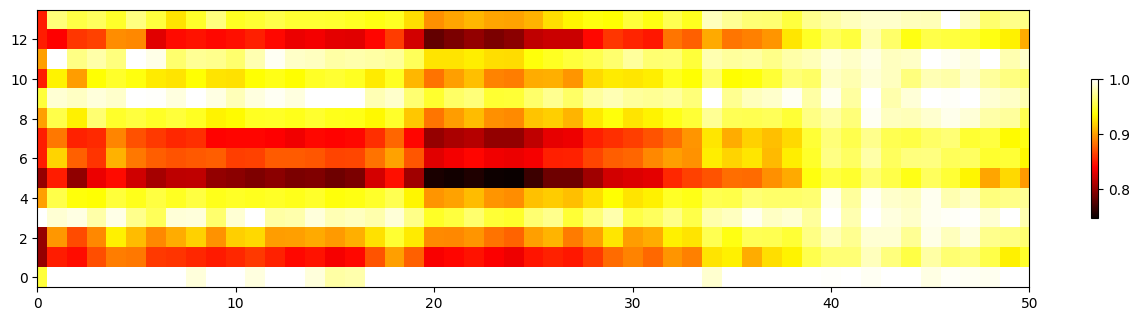

In [ ]:
rad_profile, pix_dist = get_radial_profiles(tn_list,cx,cy)
norm_rad_profile = rad_profile/np.max(rad_profile[:,:100],axis=1)[:,None]
plt.figure(figsize=(16,6))
plt.imshow(norm_rad_profile, cmap='hot')
plt.xlim([0, 100])
plt.xlabel('[pix]')
plt.ylabel('time [min]')
plt.title(tn_list[0])

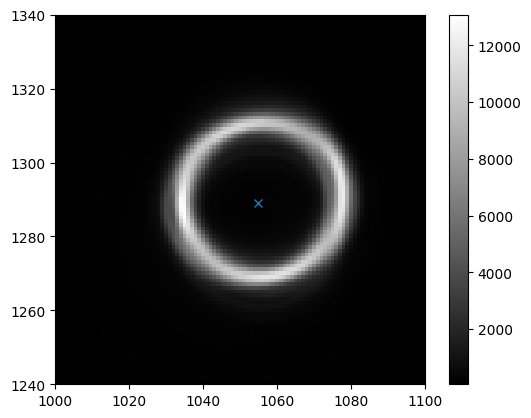

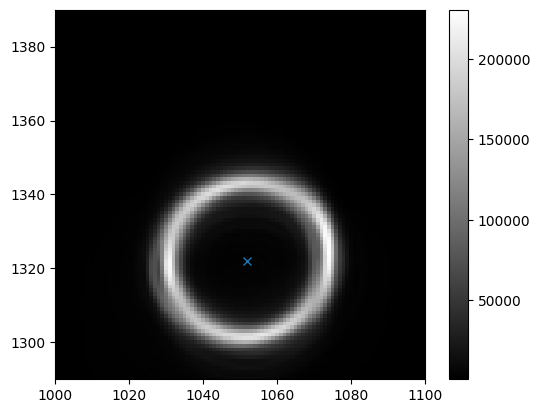

In [10]:
tnlist = ['/mnt/libero/S331sl/20260224_094931.fits',
 '/mnt/libero/S331sl/20260224_095026.fits',
 '/mnt/libero/S331sl/20260224_095121.fits',
 '/mnt/libero/S331sl/20260224_095217.fits',
 '/mnt/libero/S331sl/20260224_095312.fits',
 '/mnt/libero/S331sl/20260224_095408.fits',
 '/mnt/libero/S331sl/20260224_095503.fits',
 '/mnt/libero/S331sl/20260224_095559.fits',
 '/mnt/libero/S331sl/20260224_095654.fits',
 '/mnt/libero/S331sl/20260224_095750.fits',
 '/mnt/libero/S331sl/20260224_095845.fits',
 '/mnt/libero/S331sl/20260224_095941.fits',
 '/mnt/libero/S331sl/20260224_100036.fits',
 '/mnt/libero/S331sl/20260224_100132.fits',
 '/mnt/libero/S331sl/20260224_100227.fits',
 '/mnt/libero/S331sl/20260224_100323.fits',
 '/mnt/libero/S331sl/20260224_100418.fits',
 '/mnt/libero/S331sl/20260224_100514.fits',
 '/mnt/libero/S331sl/20260224_100609.fits',
 '/mnt/libero/S331sl/20260224_100704.fits',
 '/mnt/libero/S331sl/20260224_100800.fits',
 '/mnt/libero/S331sl/20260224_100855.fits',
 '/mnt/libero/S331sl/20260224_100951.fits',
 '/mnt/libero/S331sl/20260224_101046.fits',
 '/mnt/libero/S331sl/20260224_101142.fits',
 '/mnt/libero/S331sl/20260224_101237.fits',
 '/mnt/libero/S331sl/20260224_101333.fits',
 '/mnt/libero/S331sl/20260224_101428.fits',
 '/mnt/libero/S331sl/20260224_101524.fits',
 '/mnt/libero/S331sl/20260224_101619.fits',
 '/mnt/libero/S331sl/20260224_101715.fits',
 '/mnt/libero/S331sl/20260224_101810.fits',
 '/mnt/libero/S331sl/20260224_101905.fits',
 '/mnt/libero/S331sl/20260224_102001.fits',
 '/mnt/libero/S331sl/20260224_102056.fits',
 '/mnt/libero/S331sl/20260224_102151.fits',
 '/mnt/libero/S331sl/20260224_102247.fits',
 '/mnt/libero/S331sl/20260224_102342.fits',
 '/mnt/libero/S331sl/20260224_102438.fits',
 '/mnt/libero/S331sl/20260224_102533.fits',
 '/mnt/libero/S331sl/20260224_102628.fits',
 '/mnt/libero/S331sl/20260224_102724.fits',
 '/mnt/libero/S331sl/20260224_102819.fits',
 '/mnt/libero/S331sl/20260224_102915.fits',
 '/mnt/libero/S331sl/20260224_103010.fits',
 '/mnt/libero/S331sl/20260224_103106.fits',
 '/mnt/libero/S331sl/20260224_103201.fits',
 '/mnt/libero/S331sl/20260224_103257.fits',
 '/mnt/libero/S331sl/20260224_103352.fits',
 '/mnt/libero/S331sl/20260224_103448.fits',
 '/mnt/libero/S331sl/20260224_103543.fits',
 '/mnt/libero/S331sl/20260224_103638.fits',
 '/mnt/libero/S331sl/20260224_103734.fits',
 '/mnt/libero/S331sl/20260224_103829.fits',
 '/mnt/libero/S331sl/20260224_103925.fits',
 '/mnt/libero/S331sl/20260224_104243.fits',
 '/mnt/libero/S331sl/20260224_104338.fits']
tnlist2=['20260224_144219',
 '20260224_144320',
 '20260224_144420',
 '20260224_144521',
 '20260224_144622',
 '20260224_144722',
 '20260224_144823',
 '20260224_144923',
 '20260224_145024',
 '20260224_145124',
 '20260224_145225',
 '20260224_145325',
 '20260224_145426',
 '20260224_145526',
 '20260224_145627',
 '20260224_145727',
 '20260224_145828',
 '20260224_145928',
 '20260224_150029',
 '20260224_150130',
 '20260224_150230',
 '20260224_150331',
 '20260224_150431',
 '20260224_150532',
 '20260224_150632',
 '20260224_150733',
 '20260224_150834',
 '20260224_150934',
 '20260224_151034',
 '20260224_151135',
 '20260224_151235',
 '20260224_151336',
 '20260224_151437',
 '20260224_151537',
 '20260224_151638',
 '20260224_151738',
 '20260224_151839',
 '20260224_151939',
 '20260224_152040',
 '20260224_152140',
 '20260224_152241',
 '20260224_152341',
 '20260224_152442',
 '20260224_152543',
 '20260224_152643',
 '20260224_152744',
 '20260224_152844',
 '20260224_152945',
 '20260224_153046',
 '20260224_153146',
 '20260224_153247',
 '20260224_153347',
 '20260224_153448',
 '20260224_153548',
 '20260224_153648',
 '20260224_153749',
 '20260224_153849',
 '20260224_153950',
 '20260224_154051',
 '20260224_154151']

img = plot_tn_list(tnlist,xlim=[1000,1100],ylim=[1240,1340])
cy = 1055
cx = 1289
plt.plot(cy,cx,'x')

img2 = plot_tn_list(tnlist2,xlim=[1000,1100],ylim=[1290,1390])
cy2 = 1052
cx2 = 1322
plt.plot(cy2,cx2,'x')

In [ ]:
rad_profile, pix_dist = get_radial_profiles(tnlist,cx,cy)
norm_rad_profile = rad_profile/np.max(rad_profile[:,:100],axis=1)[:,None]
plt.figure(figsize=(16,6))
plt.imshow(norm_rad_profile, cmap='hot')
plt.xlim([0, 100])
plt.xlabel('[pix]')
plt.ylabel('time [min]')
plt.title(tn_list[0])

rad_profile, pix_dist = get_radial_profiles(tnlist2,cx2,cy2)
norm_rad_profile = rad_profile/np.max(rad_profile[:,:100],axis=1)[:,None]
plt.figure(figsize=(16,6))
plt.imshow(norm_rad_profile, cmap='hot')
plt.xlim([0, 100])
plt.xlabel('[pix]')
plt.ylabel('time [min]')
plt.title(tn_list[0])

KeyboardInterrupt: 

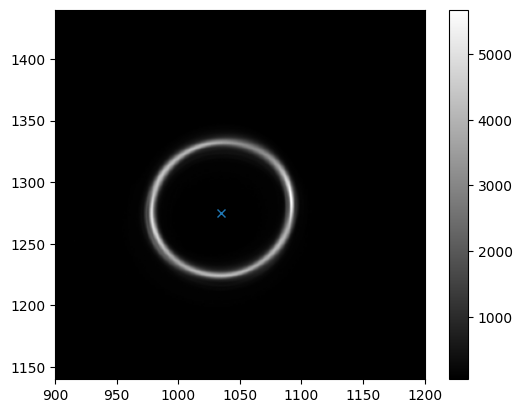

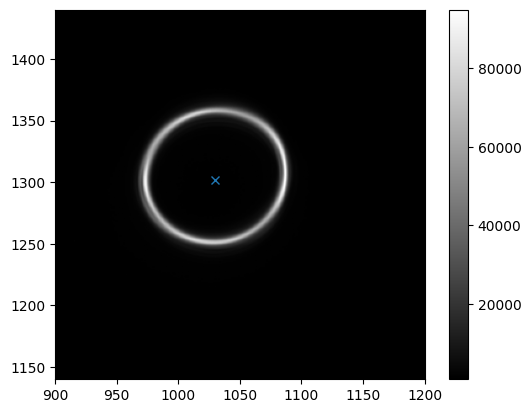

In [ ]:
tnlist = ['20260224_120125',
 '20260224_120226',
 '20260224_120326',
 '20260224_120427',
 '20260224_120527',
 '20260224_120628',
 '20260224_120728',
 '20260224_120829',
 '20260224_120929',
 '20260224_121030',
 '20260224_121130',
 '20260224_121231',
 '20260224_121331',
 '20260224_121432',
 '20260224_121532',
 '20260224_121633',
 '20260224_121733',
 '20260224_121834',
 '20260224_121934',
 '20260224_122035',
 '20260224_122135',
 '20260224_122235',
 '20260224_122336',
 '20260224_122436',
 '20260224_122537',
 '20260224_122637',
 '20260224_122738',
 '20260224_122838',
 '20260224_122938',
 '20260224_123039',
 '20260224_123139',
 '20260224_123240',
 '20260224_123341',
 '20260224_123441',
 '20260224_123542',
 '20260224_123642',
 '20260224_123743',
 '20260224_123843',
 '20260224_123944',
 '20260224_124044',
 '20260224_124145',
 '20260224_124245',
 '20260224_124346',
 '20260224_124446',
 '20260224_124547',
 '20260224_124647',
 '20260224_124747',
 '20260224_124848',
 '20260224_124948',
 '20260224_125049',
 '20260224_125149',
 '20260224_125248',
 '20260224_125348',
 '20260224_125449',
 '20260224_125550',
 '20260224_125650',
 '20260224_125751',
 '20260224_125851',
 '20260224_125951',
 '20260224_130052']
tnlist2 = ['20260224_155558',
 '20260224_155658',
 '20260224_155759',
 '20260224_155859',
 '20260224_160000',
 '20260224_160100',
 '20260224_160201',
 '20260224_160301',
 '20260224_160402',
 '20260224_160502',
 '20260224_160603',
 '20260224_160703',
 '20260224_160804',
 '20260224_160904',
 '20260224_161005',
 '20260224_161105',
 '20260224_161206',
 '20260224_161306',
 '20260224_161407',
 '20260224_161508',
 '20260224_161608',
 '20260224_161709',
 '20260224_161809',
 '20260224_161909',
 '20260224_162010',
 '20260224_162111',
 '20260224_162211',
 '20260224_162312',
 '20260224_162412',
 '20260224_162513',
 '20260224_162613',
 '20260224_162714',
 '20260224_162814',
 '20260224_162915',
 '20260224_163015',
 '20260224_163116',
 '20260224_163216',
 '20260224_163317',
 '20260224_163417',
 '20260224_163518',
 '20260224_163618',
 '20260224_163719',
 '20260224_163819',
 '20260224_163920',
 '20260224_164020',
 '20260224_164121',
 '20260224_164221',
 '20260224_164322',
 '20260224_164422',
 '20260224_164523',
 '20260224_164623',
 '20260224_164723',
 '20260224_164824',
 '20260224_164925',
 '20260224_165025',
 '20260224_165125',
 '20260224_165226',
 '20260224_165327',
 '20260224_165427',
 '20260224_165528']

img = plot_tn_list(tnlist,xlim=[900,1200],ylim=[1140,1440])
cy = 1035
cx = 1275
plt.plot(cy,cx,'x')

img2 = plot_tn_list(tnlist2,xlim=[900,1200],ylim=[1140,1440])
cy2 = 1030
cx2 = 1302
plt.plot(cy2,cx2,'x')

(0.0, 100.0)

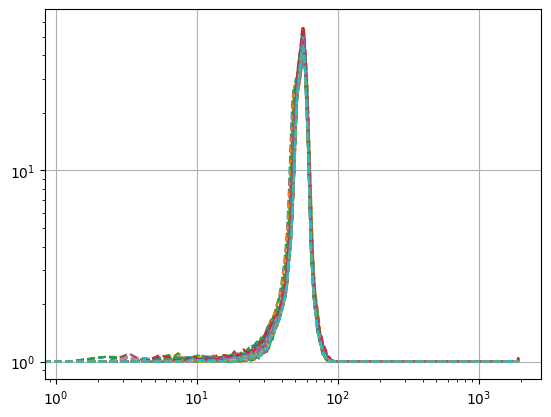

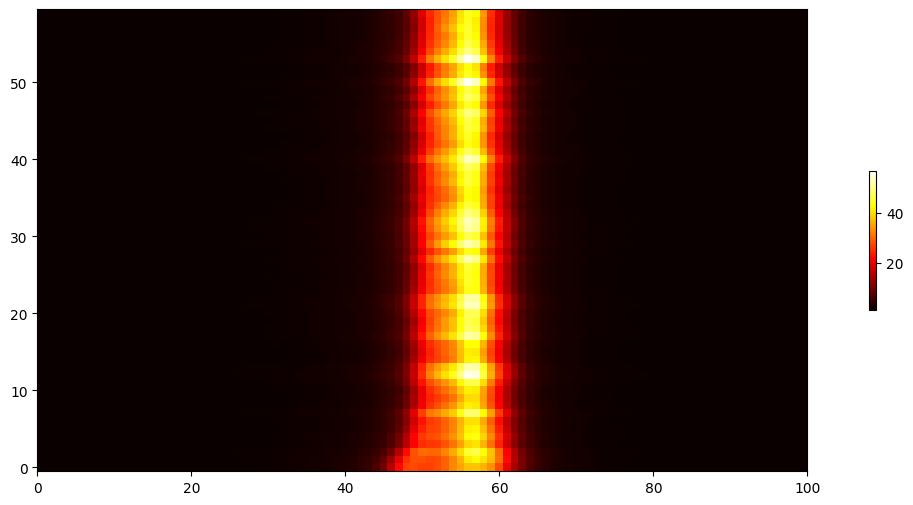

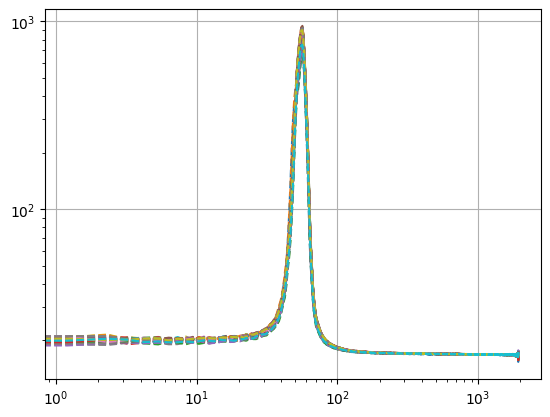

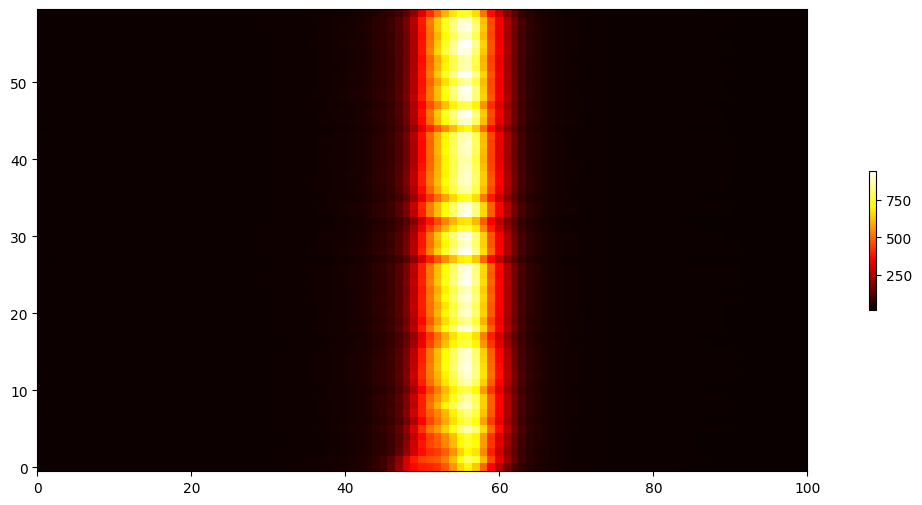

In [ ]:
rad_profile, pix_dist = get_radial_profiles(tnlist,cx,cy)
norm_rad_profile = rad_profile/np.max(rad_profile[:,:100],axis=1)[:,None]
plt.figure(figsize=(16,6))
plt.imshow(norm_rad_profile, cmap='hot')
plt.xlim([0, 100])
plt.xlabel('[pix]')
plt.ylabel('time [min]')
plt.title(tn_list[0])

rad_profile2, pix_dist = get_radial_profiles(tnlist2,cx2,cy2)
norm_rad_profile = rad_profile/np.max(rad_profile[:,:100],axis=1)[:,None]
plt.figure(figsize=(16,6))
plt.imshow(norm_rad_profile, cmap='hot')
plt.xlim([0, 100])
plt.xlabel('[pix]')
plt.ylabel('time [min]')
plt.title(tn_list[0])